<a href="https://colab.research.google.com/github/dalssam/MBI806B/blob/main/MBI806B_Assignment_270910902.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

Saving clients_cleaned.csv to clients_cleaned (1).csv
Saving transactions_cleaned.csv to transactions_cleaned (1).csv


In [2]:
clients = pd.read_csv('clients_cleaned.csv')
tx = pd.read_csv('transactions_cleaned.csv')

print(clients.shape)
print(tx.shape)

(2000, 14)
(50000, 14)


In [3]:
print(tx['transaction_type'].value_counts())

transaction_type
Check    12545
Wire     12513
ACH      12505
SWIFT    12437
Name: count, dtype: int64


In [4]:
# transaction_type risk mapping
# SWIFT: highest, per FATF Recommendation 16 (Travel Rule), which targets
#   international wire transfers specifically due to correspondent banking
#   chain opacity risk
# Wire: second, R.16 also covers domestic wire transfers, but without the
#   cross-border correspondent chain SWIFT specifically carries
# Check: middle, real fraud/kiting typology exists but with a domestic paper trail
# ACH: lowest. Note: ACH as a named system does not exist in New Zealand.
#   This report treats the ACH category as standing in for New Zealand's own
#   domestic batch clearing system, administered by Payments NZ (BECS-based
#   direct credit/direct debit), since no equivalent NZ-specific label exists
#   in the source data.
tx_type_risk_points = {'SWIFT': 100, 'Wire': 70, 'Check': 45, 'ACH': 20}

tx['type_risk_points'] = tx['transaction_type'].map(tx_type_risk_points)

print(tx[['transaction_type', 'type_risk_points']].drop_duplicates())

  transaction_type  type_risk_points
0            Check                45
1            SWIFT               100
3             Wire                70
9              ACH                20


In [5]:
tx['cross_border'] = (tx['client_country'] != tx['counterparty_country']).astype(int)

agg = tx.groupby('client_id').agg(
    tx_count=('transaction_id', 'count'),
    avg_amount=('amount', 'mean'),
    total_amount=('amount', 'sum'),
    mix_score=('type_risk_points', 'mean'),
    pct_structuring=('structuring_pattern_flag', 'mean'),
    pct_rapid=('rapid_movement_flag', 'mean'),
    pct_mispricing=('trade_mispricing_flag', 'mean'),
    pct_ofac_match=('ofac_match_flag', 'mean'),
    pct_cross_border=('cross_border', 'mean'),
    distinct_counterparty_countries=('counterparty_country', 'nunique'),
).reset_index()

print(agg.shape)
print(agg.head())

(2000, 11)
   client_id  tx_count    avg_amount  total_amount  mix_score  \
0          1        26  10045.459231     261181.94  67.500000   
1          2        28   2122.535357      59430.99  57.500000   
2          3        25   2476.962400      61924.06  54.000000   
3          4        29   7249.189655     210226.50  70.172414   
4          5        22   2791.830909      61420.28  62.954545   

   pct_structuring  pct_rapid  pct_mispricing  pct_ofac_match  \
0              0.0   0.038462             0.0        0.000000   
1              0.0   0.000000             0.0        0.000000   
2              0.0   0.040000             0.0        0.880000   
3              0.0   0.068966             0.0        0.034483   
4              0.0   0.000000             0.0        0.000000   

   pct_cross_border  distinct_counterparty_countries  
0          0.846154                               12  
1          0.750000                               10  
2          1.000000                       

In [6]:
df = clients.merge(agg, on='client_id', how='left')
print(df.shape)
print(df['tx_count'].isnull().sum())

(2000, 24)
0


In [7]:
# For each county's fatf_country_flag, ofac_country_flag as dictionary
country_fatf = clients.drop_duplicates('country').set_index('country')['fatf_country_flag'].to_dict()
country_ofac = clients.drop_duplicates('country').set_index('country')['ofac_country_flag'].to_dict()

# counterparty country FATF/OFAC?
tx['counterparty_fatf'] = tx['counterparty_country'].map(country_fatf).fillna(0)
tx['counterparty_ofac'] = tx['counterparty_country'].map(country_ofac).fillna(0)

agg2 = tx.groupby('client_id').agg(
    pct_counterparty_fatf=('counterparty_fatf', 'mean'),
    pct_counterparty_ofac=('counterparty_ofac', 'mean'),
    pct_tx_fatf=('fatf_country_flag', 'mean'),
).reset_index()

df = df.merge(agg2, on='client_id', how='left')
print(df.shape)

(2000, 27)


In [8]:
# Pillar 1: Customer Risk (0-100)
# sanctions_flag and pep_flag are deliberately excluded from this weighted sum.
# Both are handled separately as hard overrides after the composite score is built,
# since they reflect a mandatory compliance response rather than a graduated risk factor.
# See note below for why the two are treated as overrides for different reasons.

client_type_points = {'Individual': 6.25, 'Corporate': 12.5, 'Financial Institution': 18.75, 'NGO': 25}
sector_risk_points = {'Low': 0, 'Medium': 12.5, 'High': 25}

df['p1_client_type'] = df['client_type'].map(client_type_points)
df['p1_sector'] = df['sector_risk'].map(sector_risk_points)
df['p1_sectoral'] = df['sectoral_sanctions_flag'] * 25
df['p1_opacity'] = df['ownership_opacity_score'] * 25

df['customer_risk_score'] = df[['p1_client_type', 'p1_sector',
                                  'p1_sectoral', 'p1_opacity']].sum(axis=1)

print(df['customer_risk_score'].describe())

count    2000.000000
mean       40.915625
std        20.595877
min         6.250000
25%        25.000000
50%        37.500000
75%        56.250000
max       100.000000
Name: customer_risk_score, dtype: float64


In [9]:
# Pillar 2: Country Risk
# Country Risk based on the client's country.

df['p2_client_embargo_override'] = (df['fatf_country_flag'] == 1)
df['country_risk_score'] = ((df['ofac_country_flag'] == 1) & (df['fatf_country_flag'] == 0)).astype(int) * 100

print(df['country_risk_score'].describe())
print("Clients hitting the embargo override:", df['p2_client_embargo_override'].sum())

count    2000.000000
mean       21.100000
std        40.812042
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       100.000000
Name: country_risk_score, dtype: float64
Clients hitting the embargo override: 179


In [10]:
# Pillar 4: Channel Risk
# Fixed at maximum for every client, per the scenario assumption in the Introduction:
# this report focuses specifically on the bank's digitally onboarded customer segment.
# This is a scenario assumption, not a derived score, so every client gets the same value.
df['channel_risk_score'] = 100.0

In [11]:
df['composite_score'] = (
    0.55 * df['customer_risk_score'] +
    0.30 * df['country_risk_score'] +
    0.15 * df['channel_risk_score']
)

def tier(row):
    if row['sanctions_flag'] == 1:
        return 'High'
    if row['pep_flag'] == 1:
        return 'High'
    if row['p2_client_embargo_override']:
        return 'High'
    if row['composite_score'] >= 71:
        return 'High'
    elif row['composite_score'] >= 41:
        return 'Medium'
    else:
        return 'Low'

df['risk_tier'] = df.apply(tier, axis=1)

review_cycle = {'High': '1 year', 'Medium': '3 years', 'Low': '5 years'}
df['review_cycle'] = df['risk_tier'].map(review_cycle)

print(df['composite_score'].describe())
print(df['risk_tier'].value_counts())

count    2000.000000
mean       43.833594
std        16.868795
min        18.437500
25%        32.187500
50%        42.500000
75%        55.312500
max       100.000000
Name: composite_score, dtype: float64
risk_tier
Low       799
Medium    725
High      476
Name: count, dtype: int64


In [12]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Ongoing monitoring features only. Everything here is information that only
# exists once transactions accumulate, none of it is known at onboarding.
feature_cols = [
    'mix_score',                       # payment behaviour, not product risk (see limitations note)
    'pct_structuring',
    'pct_rapid',
    'pct_mispricing',
    'pct_ofac_match',
    'pct_counterparty_fatf',
    'pct_counterparty_ofac',
    'pct_tx_fatf',
    'tx_count',
    'avg_amount',
    'total_amount',
    'distinct_counterparty_countries',
    'pct_cross_border',
]

X = df[feature_cols]
print(X.shape)
print(X.isnull().sum())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(n_estimators=300, contamination=0.05, random_state=42, n_jobs=-1)
df['anomaly_flag'] = iso.fit_predict(X_scaled)
df['anomaly_score'] = iso.decision_function(X_scaled)
df['is_anomalous'] = (df['anomaly_flag'] == -1)

print(df['is_anomalous'].value_counts())

(2000, 13)
mix_score                          0
pct_structuring                    0
pct_rapid                          0
pct_mispricing                     0
pct_ofac_match                     0
pct_counterparty_fatf              0
pct_counterparty_ofac              0
pct_tx_fatf                        0
tx_count                           0
avg_amount                         0
total_amount                       0
distinct_counterparty_countries    0
pct_cross_border                   0
dtype: int64
is_anomalous
False    1900
True      100
Name: count, dtype: int64


In [13]:
print(pd.crosstab(df['risk_tier'], df['is_anomalous']))

is_anomalous  False  True 
risk_tier                 
High            416     60
Low             777     22
Medium          707     18


In [14]:
blind_spot = df[(df['risk_tier'].isin(['Low', 'Medium'])) & (df['is_anomalous'])]
print(len(blind_spot))

inspect_cols = ['client_id', 'risk_tier', 'composite_score', 'anomaly_score',
                 'mix_score', 'pct_structuring', 'pct_rapid', 'pct_mispricing',
                 'pct_ofac_match', 'pct_counterparty_fatf', 'pct_counterparty_ofac',
                 'tx_count', 'avg_amount', 'distinct_counterparty_countries']

print(blind_spot[inspect_cols].sort_values('anomaly_score').to_string(index=False))

# compare blind spot group's feature means against the rest of the population
rest = df[~((df['risk_tier'].isin(['Low', 'Medium'])) & (df['is_anomalous']))]
compare_cols = ['mix_score', 'pct_structuring', 'pct_rapid', 'pct_mispricing',
                 'pct_ofac_match', 'pct_counterparty_fatf', 'pct_counterparty_ofac',
                 'tx_count', 'avg_amount', 'distinct_counterparty_countries', 'pct_cross_border']
print(pd.DataFrame({
    'blind_spot_mean': blind_spot[compare_cols].mean(),
    'rest_mean': rest[compare_cols].mean(),
}))

40
 client_id risk_tier  composite_score  anomaly_score  mix_score  pct_structuring  pct_rapid  pct_mispricing  pct_ofac_match  pct_counterparty_fatf  pct_counterparty_ofac  tx_count   avg_amount  distinct_counterparty_countries
      1791    Medium          65.6250      -0.105251  45.000000         0.000000   0.100000             0.0        0.100000               0.100000               0.100000        10  1412.227000                                7
       779    Medium          45.9375      -0.095657  68.250000         0.000000   0.100000             0.0        0.050000               0.050000               0.050000        20 23277.287000                               11
       914    Medium          56.2500      -0.068876  68.750000         0.000000   0.000000             0.0        0.062500               0.062500               0.062500        16 17825.245625                               11
      1121    Medium          45.9375      -0.066509  61.730769         0.038462   0.115385  

In [15]:
# Does ofac_match_flag simply equal "is counterparty_country in the OFAC list"?
tx['counterparty_ofac_check'] = tx['counterparty_country'].map(country_ofac).fillna(0)
mismatch = (tx['ofac_match_flag'] != tx['counterparty_ofac_check'])
print("Transactions where ofac_match_flag disagrees with counterparty country OFAC status:", mismatch.sum())
print("Total transactions:", len(tx))

Transactions where ofac_match_flag disagrees with counterparty country OFAC status: 0
Total transactions: 50000


In [16]:
# Check if transaction-level fatf_country_flag is also just a copy of counterparty country status
tx['counterparty_fatf_check'] = tx['counterparty_country'].map(country_fatf).fillna(0)
mismatch_fatf = (tx['fatf_country_flag'] != tx['counterparty_fatf_check'])
print("Transactions where tx-level fatf_country_flag disagrees with counterparty country FATF status:", mismatch_fatf.sum())
print("Total transactions:", len(tx))

Transactions where tx-level fatf_country_flag disagrees with counterparty country FATF status: 0
Total transactions: 50000


In [17]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# pct_ofac_match and pct_tx_fatf were found to be exact duplicates of
# pct_counterparty_ofac and pct_counterparty_fatf (0/50,000 transactions differ).
# Removed here to avoid double-weighting the same underlying signal.
feature_cols = [
    'mix_score',
    'pct_structuring',
    'pct_rapid',
    'pct_mispricing',
    'pct_counterparty_fatf',
    'pct_counterparty_ofac',
    'tx_count',
    'avg_amount',
    'total_amount',
    'distinct_counterparty_countries',
    'pct_cross_border',
]

X = df[feature_cols]
print(X.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(n_estimators=300, contamination=0.05, random_state=42, n_jobs=-1)
df['anomaly_flag'] = iso.fit_predict(X_scaled)
df['anomaly_score'] = iso.decision_function(X_scaled)
df['is_anomalous'] = (df['anomaly_flag'] == -1)

print(df['is_anomalous'].value_counts())
print(pd.crosstab(df['risk_tier'], df['is_anomalous']))

(2000, 11)
is_anomalous
False    1900
True      100
Name: count, dtype: int64
is_anomalous  False  True 
risk_tier                 
High            414     62
Low             782     17
Medium          704     21


In [18]:
blind_spot = df[(df['risk_tier'].isin(['Low', 'Medium'])) & (df['is_anomalous'])]
rest = df[~((df['risk_tier'].isin(['Low', 'Medium'])) & (df['is_anomalous']))]

print(len(blind_spot))

compare_cols = ['mix_score', 'pct_structuring', 'pct_rapid', 'pct_mispricing',
                 'pct_counterparty_fatf', 'pct_counterparty_ofac',
                 'tx_count', 'avg_amount', 'total_amount',
                 'distinct_counterparty_countries', 'pct_cross_border']

comparison = pd.DataFrame({
    'blind_spot_mean': blind_spot[compare_cols].mean(),
    'rest_mean': rest[compare_cols].mean(),
    'blind_spot_median': blind_spot[compare_cols].median(),
    'rest_median': rest[compare_cols].median(),
})
comparison['mean_ratio'] = comparison['blind_spot_mean'] / comparison['rest_mean']
print(comparison)

38
                                 blind_spot_mean      rest_mean  \
mix_score                              59.964740      58.666284   
pct_structuring                         0.025656       0.006629   
pct_rapid                               0.075485       0.048632   
pct_mispricing                          0.000000       0.000236   
pct_counterparty_fatf                   0.023046       0.011759   
pct_counterparty_ofac                   0.033504       0.035475   
tx_count                               23.078947      25.037207   
avg_amount                          11002.196546    4051.446601   
total_amount                       273817.796316  101631.914735   
distinct_counterparty_countries        11.000000      11.426096   
pct_cross_border                        0.920951       0.952288   

                                 blind_spot_median   rest_median  mean_ratio  
mix_score                                61.023810     58.428571    1.022133  
pct_structuring                   

In [19]:
print(blind_spot['avg_amount'].describe())
print(rest['avg_amount'].describe())

count       38.000000
mean     11002.196546
std       6120.177704
min        995.946000
25%       7187.224953
50%      11695.010252
75%      16336.262387
max      23277.287000
Name: avg_amount, dtype: float64
count     1962.000000
mean      4051.446601
std       2877.519373
min       1037.978750
25%       1969.512917
50%       2620.747943
75%       5612.625278
max      25248.212632
Name: avg_amount, dtype: float64


In [20]:
one_client = df[df['client_id'] == 337]
print(one_client[['client_id', 'risk_tier', 'anomaly_score'] + feature_cols].T)

# where does this client sit relative to the whole population, percentile-wise?
for col in feature_cols:
    pct = (df[col] < one_client[col].values[0]).mean() * 100
    print(f"{col}: value={one_client[col].values[0]:.3f}, percentile={pct:.1f}")

                                       336
client_id                              337
risk_tier                              Low
anomaly_score                    -0.003062
mix_score                        48.666667
pct_structuring                        0.0
pct_rapid                              0.0
pct_mispricing                         0.0
pct_counterparty_fatf                  0.0
pct_counterparty_ofac                  0.0
tx_count                                15
avg_amount                         995.946
total_amount                      14939.19
distinct_counterparty_countries          8
pct_cross_border                  0.733333
mix_score: value=48.667, percentile=4.9
pct_structuring: value=0.000, percentile=0.0
pct_rapid: value=0.000, percentile=0.0
pct_mispricing: value=0.000, percentile=0.0
pct_counterparty_fatf: value=0.000, percentile=0.0
pct_counterparty_ofac: value=0.000, percentile=0.0
tx_count: value=15.000, percentile=1.1
avg_amount: value=995.946, percentile=0.0
tota

In [21]:
blind_spot_sorted = blind_spot.sort_values('avg_amount')
print(blind_spot_sorted[['client_id', 'avg_amount', 'tx_count', 'distinct_counterparty_countries', 'pct_cross_border']].head(8))

      client_id   avg_amount  tx_count  distinct_counterparty_countries  \
336         337   995.946000        15                                8   
1790       1791  1412.227000        10                                7   
1833       1834  1553.337500        12                                7   
1885       1886  1568.618571        14                                8   
1819       1820  2256.816667        18                               10   
969         970  2377.436364        22                                9   
849         850  2720.582000        15                                9   
1497       1498  3015.041250        16                                6   

      pct_cross_border  
336           0.733333  
1790          1.000000  
1833          0.916667  
1885          1.000000  
1819          0.888889  
969           0.772727  
849           1.000000  
1497          1.000000  


Axes(0.125,0.11;0.775x0.77)
Low-amount half: n= 19 tx_count mean= 20.526315789473685
High-amount half: n= 19 tx_count mean= 25.63157894736842


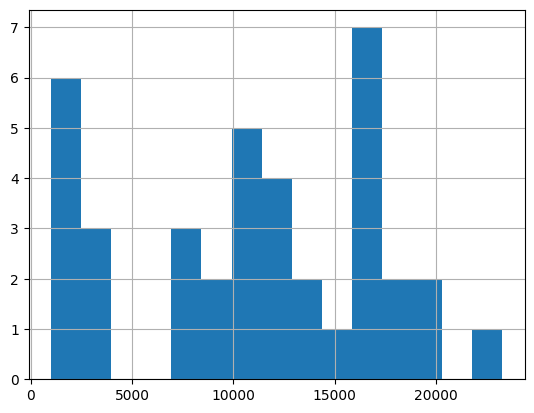

In [22]:
import numpy as np
print(blind_spot['avg_amount'].hist(bins=15))

# split blind spot into two rough halves by amount and compare tx_count
low_half = blind_spot[blind_spot['avg_amount'] < blind_spot['avg_amount'].median()]
high_half = blind_spot[blind_spot['avg_amount'] >= blind_spot['avg_amount'].median()]

print("Low-amount half: n=", len(low_half), "tx_count mean=", low_half['tx_count'].mean())
print("High-amount half: n=", len(high_half), "tx_count mean=", high_half['tx_count'].mean())

In [23]:
low_amount_group = blind_spot[blind_spot['avg_amount'] < blind_spot['avg_amount'].median()]

print(low_amount_group[['client_id', 'avg_amount', 'tx_count', 'pct_structuring']].merge(
    df[['client_id', 'sector', 'sector_risk', 'client_type']], on='client_id'
).to_string(index=False))

print()
print("Sector risk distribution among low-amount blind spot clients:")
print(low_amount_group.merge(df[['client_id', 'sector_risk']], on='client_id')['sector_risk'].value_counts())

print()
print("Compare to overall population sector_risk distribution:")
print(df['sector_risk'].value_counts(normalize=True))

 client_id   avg_amount  tx_count  pct_structuring          sector sector_risk           client_type
       337   995.946000        15         0.000000            Tech         Low             Corporate
       363  9968.734800        25         0.040000 Casino/Gambling        High             Corporate
       426 11334.747826        23         0.043478 Crypto Exchange        High             Corporate
       523  7064.593462        26         0.038462 Casino/Gambling        High             Corporate
       539 11375.073421        38         0.000000      Energy/Oil        High             Corporate
       721  7818.112941        17         0.058824     NGO/Charity        High             Corporate
       847  9358.340000        23         0.043478 Casino/Gambling        High            Individual
       850  2720.582000        15         0.066667   Import/Export      Medium            Individual
       856 10008.521053        19         0.052632     NGO/Charity        High Financial In

KeyError: 'sector_risk'

In [24]:
print("Sector risk distribution among low-amount blind spot clients:")
print(low_amount_group['sector_risk'].value_counts())

print()
print("Compare to overall population sector_risk distribution:")
print(df['sector_risk'].value_counts(normalize=True).round(3))

Sector risk distribution among low-amount blind spot clients:
sector_risk
High      12
Low        4
Medium     3
Name: count, dtype: int64

Compare to overall population sector_risk distribution:
sector_risk
High      0.460
Medium    0.292
Low       0.248
Name: proportion, dtype: float64


In [25]:
# Install shap if not already available in this Colab session
!pip install shap --quiet

import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# ---------------------------------------------------------------
# Step 14. Random Forest surrogate model
# This does not detect anything new. It is trained to reproduce
# Isolation Forest's own anomaly flag, using the exact same features,
# purely so SHAP can explain which features drove each decision.
# ---------------------------------------------------------------

y = df['is_anomalous']  # the target IS Isolation Forest's own output, not an independent label

rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight='balanced')
rf.fit(X, y)

# Sanity check: how well does the surrogate reproduce Isolation Forest's decisions?
# This is not model accuracy in the usual sense, it is a check on whether the
# explanation that follows is trustworthy. A poor fit here would mean SHAP is
# explaining a surrogate that does not actually track Isolation Forest well.
y_pred = rf.predict(X)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00      1900
        True       0.95      1.00      0.98       100

    accuracy                           1.00      2000
   macro avg       0.98      1.00      0.99      2000
weighted avg       1.00      1.00      1.00      2000



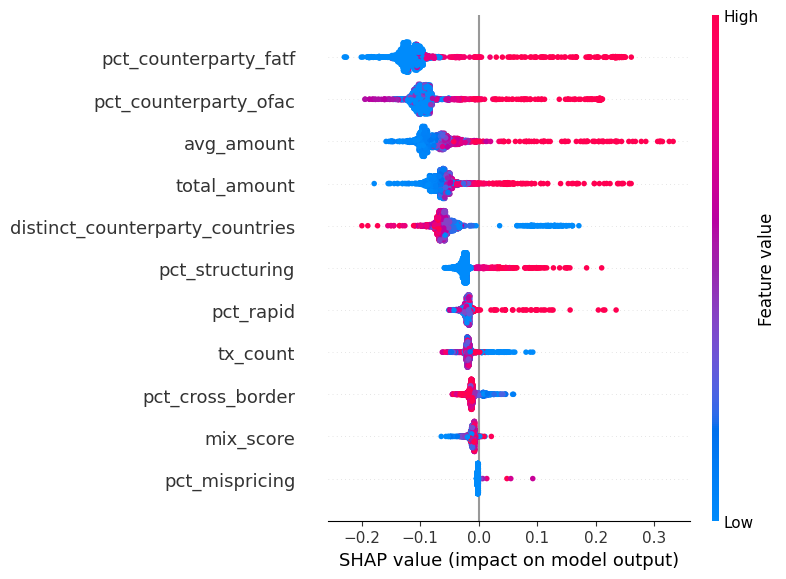

In [26]:
# ---------------------------------------------------------------
# Step 15. SHAP explanation
# ---------------------------------------------------------------
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

# shap_values has one array per class when class_weight is used;
# index 1 corresponds to the "anomalous = True" class
import numpy as np
if isinstance(shap_values, list):
    shap_values_anomalous = shap_values[1]
else:
    shap_values_anomalous = shap_values[:, :, 1]

# Global view: which features matter most across all clients
shap.summary_plot(shap_values_anomalous, X, feature_names=feature_cols)

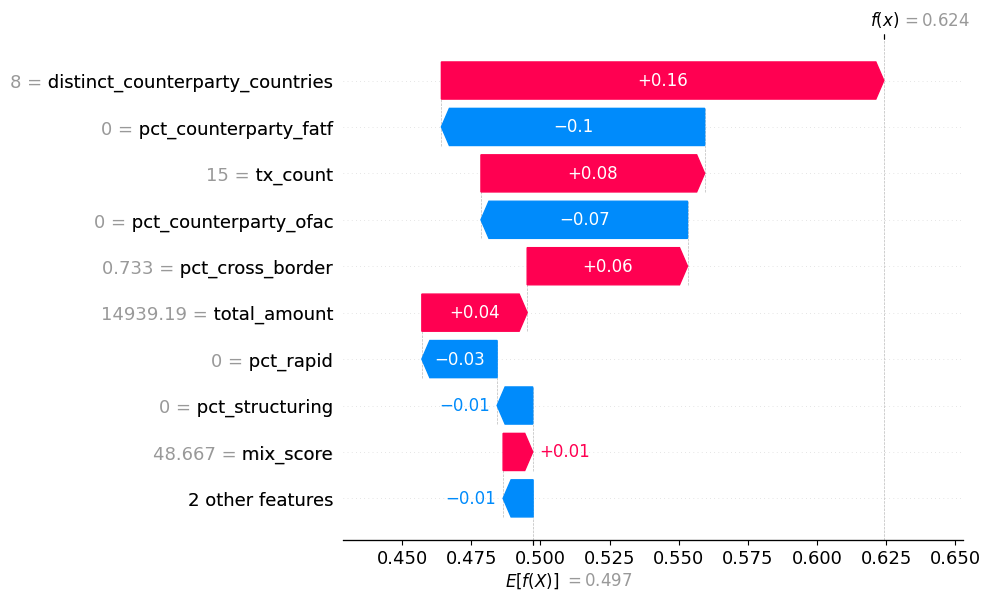

In [27]:
# Individual explanation for client 337, the "quiet" outlier case explored earlier
client_idx = df.index[df['client_id'] == 337][0]
row_position = X.index.get_loc(client_idx)

shap.waterfall_plot(shap.Explanation(
    values=shap_values_anomalous[row_position],
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
    data=X.iloc[row_position],
    feature_names=feature_cols
))

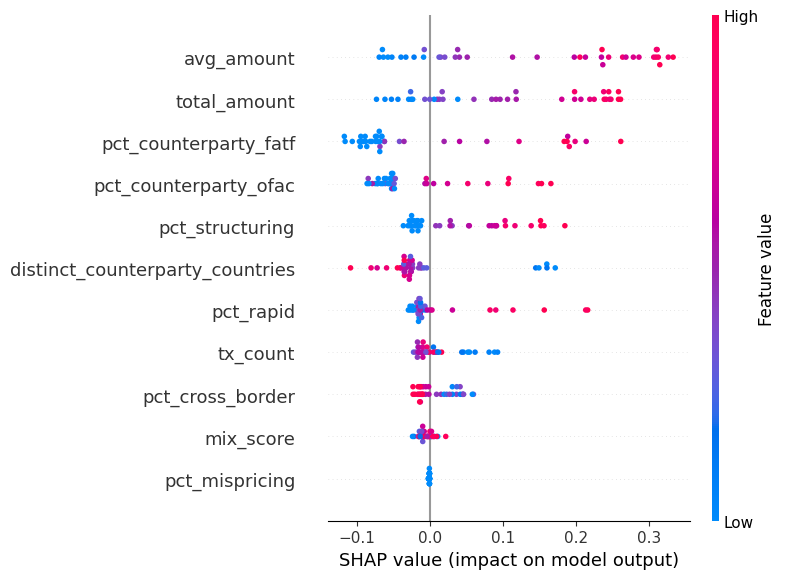

                            feature  mean_abs_shap_blind_spot
7                        avg_amount                  0.159707
8                      total_amount                  0.120317
4             pct_counterparty_fatf                  0.100413
5             pct_counterparty_ofac                  0.064900
1                   pct_structuring                  0.056374
9   distinct_counterparty_countries                  0.049892
2                         pct_rapid                  0.035907
6                          tx_count                  0.022106
10                 pct_cross_border                  0.022057
0                         mix_score                  0.008931
3                    pct_mispricing                  0.000894


In [28]:
# The global summary plot mixes two different populations: 62 already-High
# clients and 38 blind-spot clients. The report's resourcing recommendation
# is about the 38, so check SHAP importance for that subgroup specifically.

blind_spot_idx = df.index[(df['risk_tier'].isin(['Low', 'Medium'])) & (df['is_anomalous'])]
blind_spot_positions = [X.index.get_loc(i) for i in blind_spot_idx]

shap_blind_spot = shap_values_anomalous[blind_spot_positions]

shap.summary_plot(shap_blind_spot, X.iloc[blind_spot_positions], feature_names=feature_cols)

mean_abs_shap = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap_blind_spot': np.abs(shap_blind_spot).mean(axis=0)
}).sort_values('mean_abs_shap_blind_spot', ascending=False)
print(mean_abs_shap)

In [29]:
print(mean_abs_shap)

                            feature  mean_abs_shap_blind_spot
7                        avg_amount                  0.159707
8                      total_amount                  0.120317
4             pct_counterparty_fatf                  0.100413
5             pct_counterparty_ofac                  0.064900
1                   pct_structuring                  0.056374
9   distinct_counterparty_countries                  0.049892
2                         pct_rapid                  0.035907
6                          tx_count                  0.022106
10                 pct_cross_border                  0.022057
0                         mix_score                  0.008931
3                    pct_mispricing                  0.000894


# Validation

In [30]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import shap

# =================================================================
# 1. Load cleaned data
# =================================================================
clients = pd.read_csv('clients_cleaned.csv')
tx = pd.read_csv('transactions_cleaned.csv')

# =================================================================
# 2. Transaction-level engineering
# =================================================================
tx_type_risk_points = {'SWIFT': 100, 'Wire': 70, 'Check': 45, 'ACH': 20}
tx['type_risk_points'] = tx['transaction_type'].map(tx_type_risk_points)
tx['cross_border'] = (tx['client_country'] != tx['counterparty_country']).astype(int)

# =================================================================
# 3. Client-level transaction aggregation
# Note: the original transaction-level ofac_match_flag and fatf_country_flag
# were found to be exact duplicates of counterparty-country-based flags
# (0/50,000 transactions differed), so they are not aggregated separately here.
# =================================================================
agg = tx.groupby('client_id').agg(
    tx_count=('transaction_id', 'count'),
    avg_amount=('amount', 'mean'),
    total_amount=('amount', 'sum'),
    mix_score=('type_risk_points', 'mean'),
    pct_structuring=('structuring_pattern_flag', 'mean'),
    pct_rapid=('rapid_movement_flag', 'mean'),
    pct_mispricing=('trade_mispricing_flag', 'mean'),
    pct_cross_border=('cross_border', 'mean'),
    distinct_counterparty_countries=('counterparty_country', 'nunique'),
).reset_index()

country_fatf = clients.drop_duplicates('country').set_index('country')['fatf_country_flag'].to_dict()
country_ofac = clients.drop_duplicates('country').set_index('country')['ofac_country_flag'].to_dict()
tx['counterparty_fatf'] = tx['counterparty_country'].map(country_fatf).fillna(0)
tx['counterparty_ofac'] = tx['counterparty_country'].map(country_ofac).fillna(0)

agg2 = tx.groupby('client_id').agg(
    pct_counterparty_fatf=('counterparty_fatf', 'mean'),
    pct_counterparty_ofac=('counterparty_ofac', 'mean'),
).reset_index()

df = clients.merge(agg, on='client_id', how='left').merge(agg2, on='client_id', how='left')
print("Step 3 check — df shape:", df.shape)

# =================================================================
# 4. Day-1 rule-based score
# =================================================================
# Pillar 1: Customer Risk. PEP and sanctions excluded here, handled below
# as deterministic onboarding rules rather than graduated points.
client_type_points = {'Individual': 6.25, 'Corporate': 12.5, 'Financial Institution': 18.75, 'NGO': 25}
sector_risk_points = {'Low': 0, 'Medium': 12.5, 'High': 25}

df['p1_client_type'] = df['client_type'].map(client_type_points)
df['p1_sector'] = df['sector_risk'].map(sector_risk_points)
df['p1_sectoral'] = df['sectoral_sanctions_flag'] * 25
df['p1_opacity'] = df['ownership_opacity_score'] * 25
df['customer_risk_score'] = df[['p1_client_type', 'p1_sector', 'p1_sectoral', 'p1_opacity']].sum(axis=1)

# Pillar 2: Country Risk, own country only. fatf_country_flag countries
# (comprehensive embargo, matches FATF's Call for Action list) become a
# hard override rather than a weighted score.
df['p2_client_embargo_override'] = (df['fatf_country_flag'] == 1)
df['country_risk_score'] = ((df['ofac_country_flag'] == 1) & (df['fatf_country_flag'] == 0)).astype(int) * 100

# Pillar 3: Channel Risk, fixed scenario assumption (digitally onboarded segment)
df['channel_risk_score'] = 100.0

# Composite and tier
df['composite_score'] = (
    0.55 * df['customer_risk_score'] +
    0.30 * df['country_risk_score'] +
    0.15 * df['channel_risk_score']
)

def tier(row):
    if row['sanctions_flag'] == 1:
        return 'High'
    if row['pep_flag'] == 1:
        return 'High'
    if row['p2_client_embargo_override']:
        return 'High'
    if row['composite_score'] >= 71:
        return 'High'
    elif row['composite_score'] >= 41:
        return 'Medium'
    else:
        return 'Low'

df['risk_tier'] = df.apply(tier, axis=1)
df['review_cycle'] = df['risk_tier'].map({'High': '1 year', 'Medium': '3 years', 'Low': '5 years'})

print("Step 4 check — tier distribution:")
print(df['risk_tier'].value_counts())

# =================================================================
# 5. Isolation Forest — ongoing monitoring layer
# Only information that accumulates after onboarding. Day-1 fields
# (client_type, sector, PEP, sanctions, own country, opacity) are
# deliberately excluded since the rule-based score already used them.
# =================================================================
feature_cols = [
    'mix_score', 'pct_structuring', 'pct_rapid', 'pct_mispricing',
    'pct_counterparty_fatf', 'pct_counterparty_ofac',
    'tx_count', 'avg_amount', 'total_amount',
    'distinct_counterparty_countries', 'pct_cross_border',
]
X = df[feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(n_estimators=300, contamination=0.05, random_state=42, n_jobs=-1)
df['anomaly_flag'] = iso.fit_predict(X_scaled)
df['anomaly_score'] = iso.decision_function(X_scaled)
df['is_anomalous'] = (df['anomaly_flag'] == -1)

print("Step 5 check — anomaly count and crosstab:")
print(df['is_anomalous'].value_counts())
print(pd.crosstab(df['risk_tier'], df['is_anomalous']))

blind_spot = df[(df['risk_tier'].isin(['Low', 'Medium'])) & (df['is_anomalous'])]
already_high = df[(df['risk_tier'] == 'High') & (df['is_anomalous'])]
print(f"Blind spot (Low/Medium, anomalous): {len(blind_spot)}")
print(f"Already High, also anomalous: {len(already_high)}")
print("Blind spot avg_amount mean:", blind_spot['avg_amount'].mean(), "| rest:", df[~df.index.isin(blind_spot.index)]['avg_amount'].mean())

# =================================================================
# 6. Random Forest surrogate + SHAP
# Not an independent detector. Trained to reproduce Isolation Forest's
# own anomaly flag, purely to make that decision explainable.
# =================================================================
y = df['is_anomalous']
rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight='balanced')
rf.fit(X, y)
print("Step 6 check — surrogate fidelity:")
print(classification_report(y, rf.predict(X)))

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)
shap_values_anomalous = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]

blind_spot_positions = [X.index.get_loc(i) for i in blind_spot.index]
shap_blind_spot = shap_values_anomalous[blind_spot_positions]

mean_abs_shap = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap_blind_spot': np.abs(shap_blind_spot).mean(axis=0)
}).sort_values('mean_abs_shap_blind_spot', ascending=False)
print(mean_abs_shap)

Step 3 check — df shape: (2000, 25)
Step 4 check — tier distribution:
risk_tier
Low       799
Medium    725
High      476
Name: count, dtype: int64
Step 5 check — anomaly count and crosstab:
is_anomalous
False    1900
True      100
Name: count, dtype: int64
is_anomalous  False  True 
risk_tier                 
High            414     62
Low             782     17
Medium          704     21
Blind spot (Low/Medium, anomalous): 38
Already High, also anomalous: 62
Blind spot avg_amount mean: 11002.196545587653 | rest: 4051.446600830622
Step 6 check — surrogate fidelity:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      1900
        True       0.95      1.00      0.98       100

    accuracy                           1.00      2000
   macro avg       0.98      1.00      0.99      2000
weighted avg       1.00      1.00      1.00      2000

                            feature  mean_abs_shap_blind_spot
7                        avg_amount   